Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


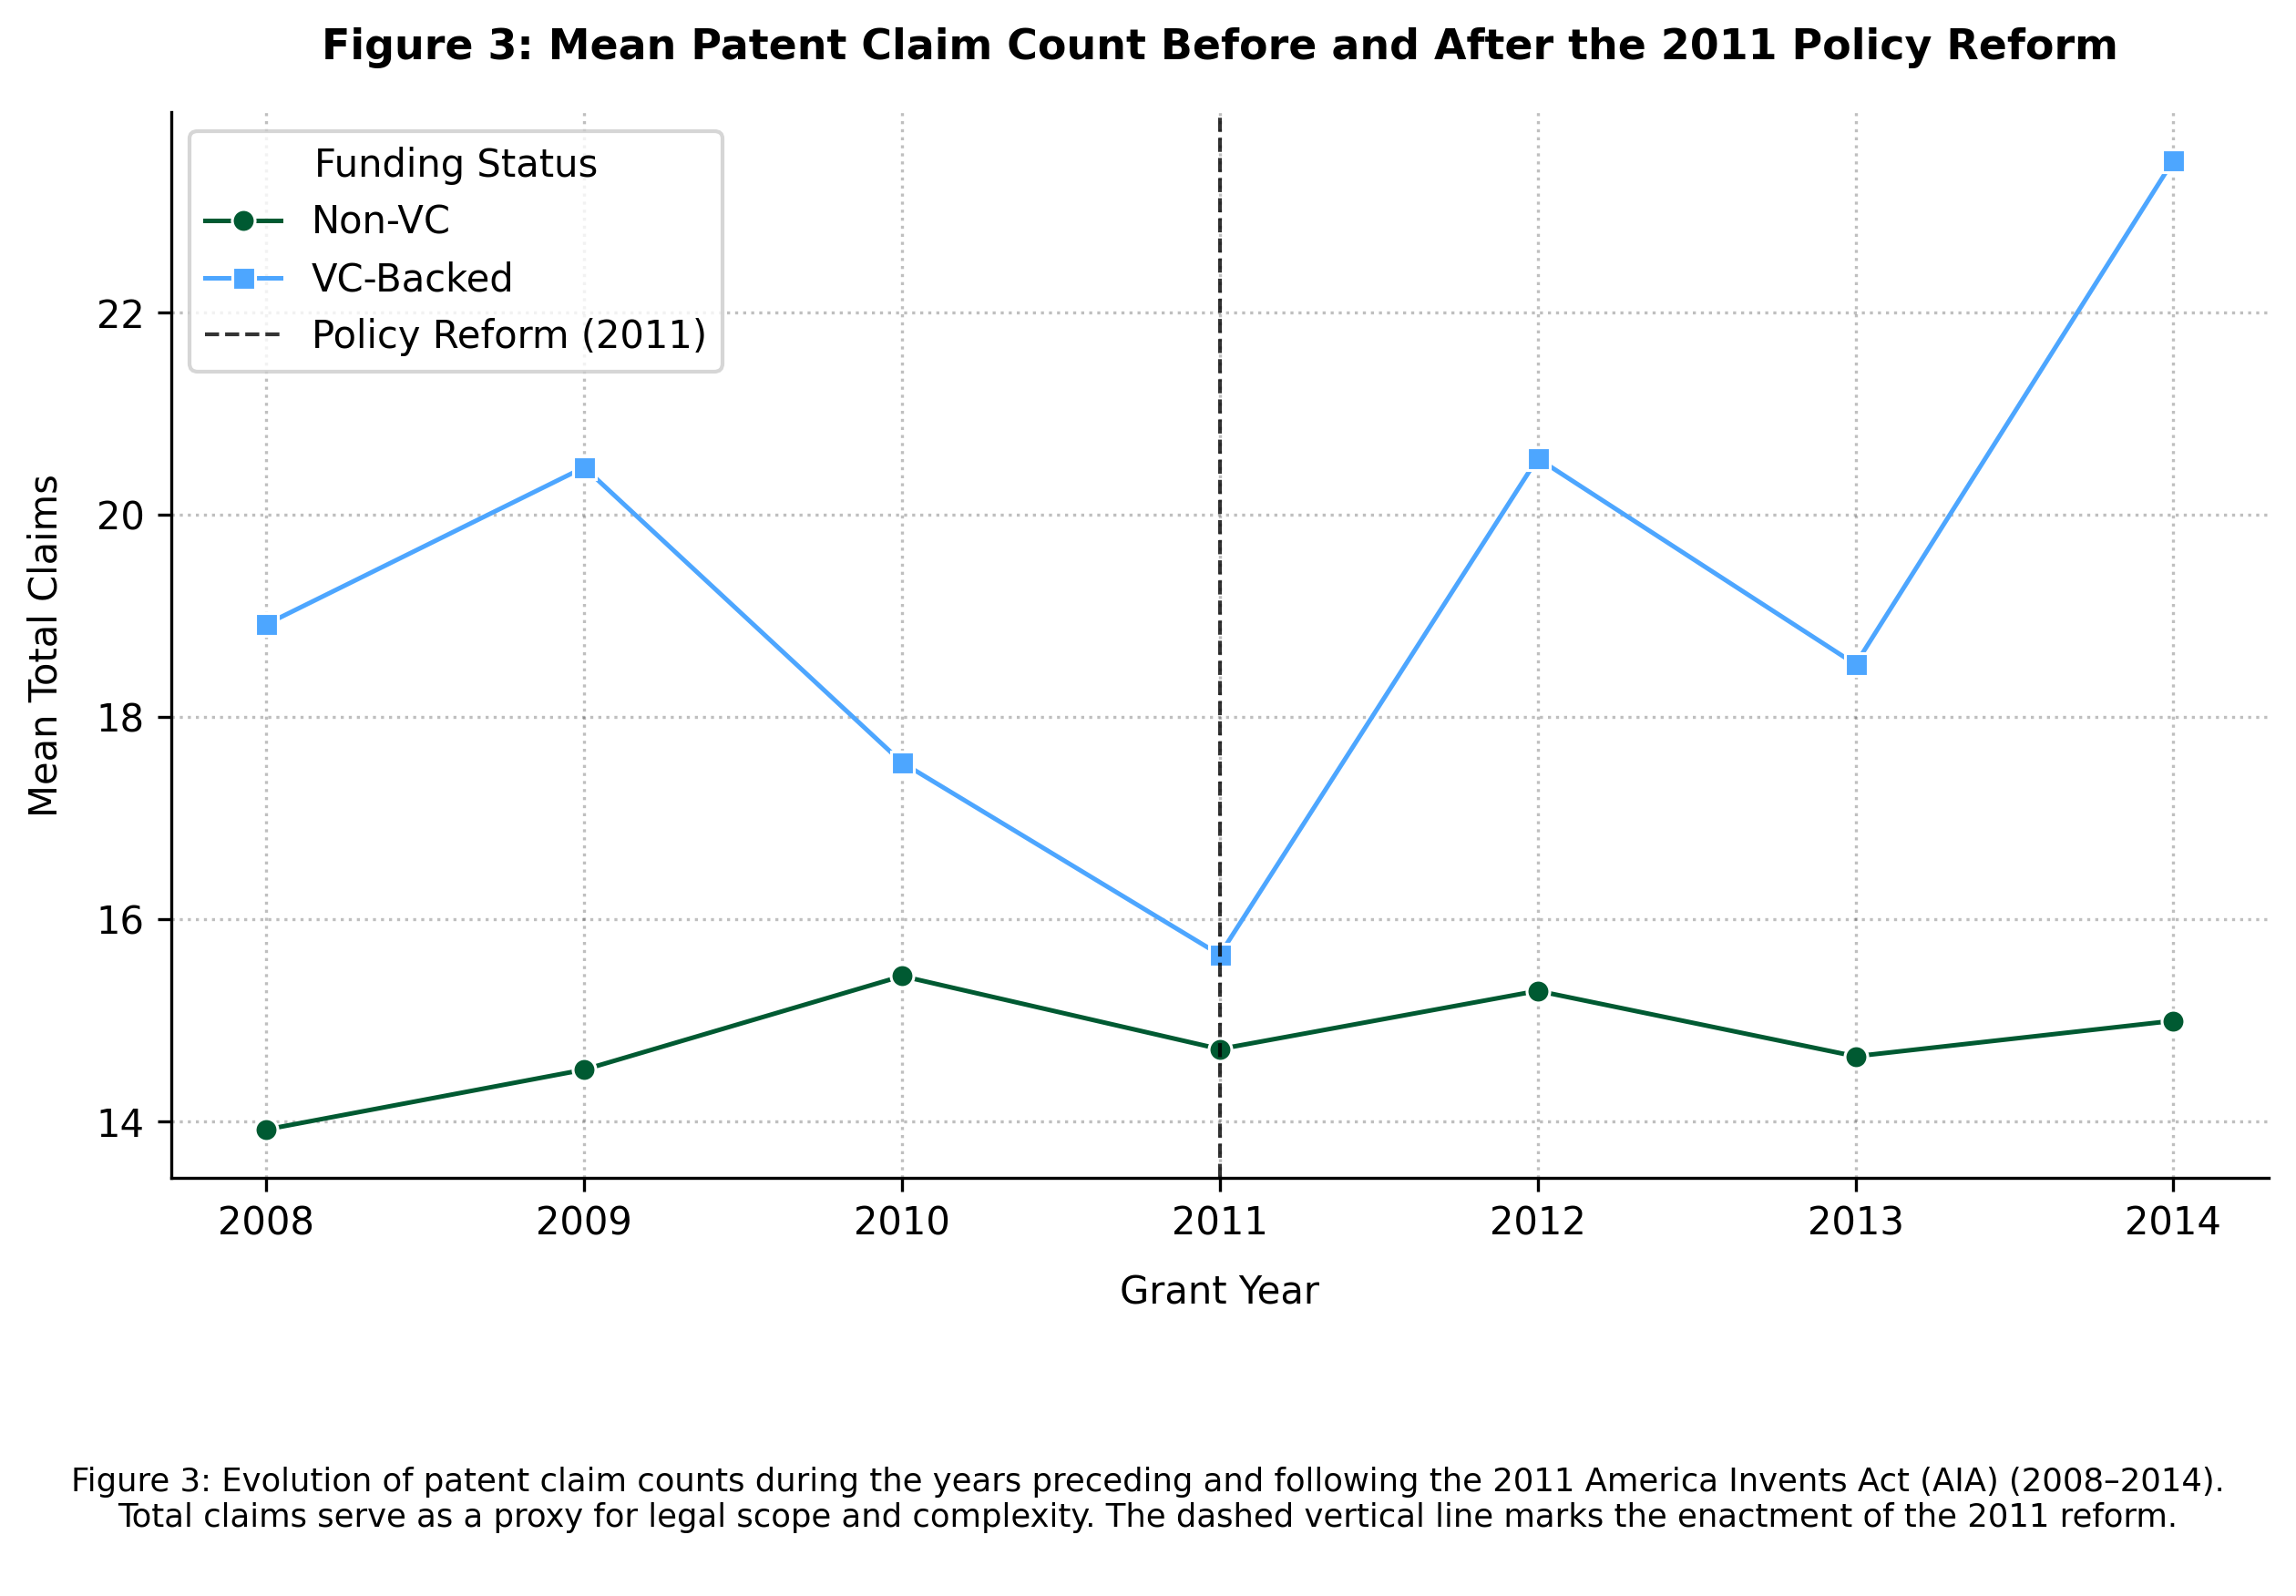

In [2]:
import os
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

#funcitons
def load_claims_trend_data(parquet_file, start_year=2008, end_year=2014):
    con = duckdb.connect()
    df = con.execute(f"""
        SELECT
            grant_year,
            CASE WHEN vc_backed = 1 THEN 'VC-Backed' ELSE 'Non-VC' END AS vc_status,
            AVG(total_claims) AS mean_claims
        FROM '{parquet_file}'
        WHERE grant_year BETWEEN {start_year} AND {end_year}
        GROUP BY grant_year, vc_backed
        ORDER BY grant_year;
    """).df()
    return df

def configure_plot_style():
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': '#000000',
        'grid.color': '#000000',
        'grid.alpha': 0.25
    })

def plot_claims_policy_trend(df, output_path, start_year=2008, end_year=2014):
    fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)

    sns.lineplot(
        data=df,
        x='grant_year',
        y='mean_claims',
        hue='vc_status',
        style='vc_status',
        palette={'VC-Backed': '#4da6ff', 'Non-VC': '#005a32'},
        markers={'VC-Backed': 's', 'Non-VC': 'o'},
        dashes=False,
        linewidth=1.2,
        markersize=6,
        ax=ax
    )

    #2011 policy shift
    ax.axvline(2011, color='#000000', linestyle='--', linewidth=1.0, alpha=0.8, label='Policy Reform (2011)')

    ax.set_title('Figure 3: Mean Patent Claim Count Before and After the 2011 Policy Reform', fontsize=11, fontweight='bold', pad=14)
    ax.set_xlabel('Grant Year', fontsize=10, labelpad=8)
    ax.set_ylabel('Mean Total Claims', fontsize=10, labelpad=8)
    ax.set_xticks(range(start_year, end_year + 1))
    ax.grid(True, linestyle=':')

    ax.legend(title='Funding Status', frameon=True, loc='upper left')

    caption = (
        "Figure 3: Evolution of patent claim counts during the years preceding and following the 2011 America Invents Act (AIA) (2008–2014).\n"
        "Total claims serve as a proxy for legal scope and complexity. The dashed vertical line marks the enactment of the 2011 reform.\n"
    )
    plt.figtext(0.5, -0.15, caption, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

#figure 3

#setup paths and load data
drive_mount_point = os.path.join(os.sep, "content", "drive")
drive.mount(drive_mount_point, force_remount=False)

drive_data_dir = os.path.join(drive_mount_point, "MyDrive", "data")
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

df_claims_trend = load_claims_trend_data(parquet_path, start_year=2008, end_year=2014)

configure_plot_style()
fig3_path = os.path.join(drive_data_dir, "figure3_claims_policy_trend.png")
plot_claims_policy_trend(df_claims_trend, fig3_path, start_year=2008, end_year=2014)